# PRD: Intelligent Dispatch Pipeline

## Module A — Spatio-Temporal Deduplication Engine
Detect and merge duplicate 311 tickets: same physical location (<50m) + similar text (cosine >85%) + within active time window.

## Module B — NLP Smart Router
Predict the responsible department from free-text `case_title`, with SHAP explainability.

Both modules feed into the Streamlit dashboard (Module C).

In [1]:
import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from math import radians, sin, cos, sqrt, atan2
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_parquet("/Users/rayxu/CS506_Final_Project/problemstic/boston_311_with_svi.parquet")
df["open_dt"] = pd.to_datetime(df["open_dt"], utc=True)
print(f"Records: {len(df):,}")
print(f"With case_title: {df['case_title'].notna().sum():,}")
print(f"Unique case_titles: {df['case_title'].nunique():,}")
print(f"Unique departments: {df['department'].nunique()}")

Records: 1,605,853
With case_title: 1,605,826
Unique case_titles: 18,265
Unique departments: 19


---
# Module A: Spatio-Temporal Deduplication Engine

**Logic**: For each incoming ticket, scan existing open tickets within 50m. If text similarity >85%, flag as duplicate.

**Business value**: Avoid redundant dispatches to the same incident.

In [2]:
def haversine_m(lat1, lon1, lat2, lon2):
    """Haversine distance in meters between two points."""
    R = 6371000  # Earth radius in meters
    lat1, lon1, lat2, lon2 = map(radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))


def find_duplicates(df, radius_m=50, sim_threshold=0.85):
    """
    Scan for spatio-temporal duplicate tickets.
    
    Groups by (type, date) for tractable pairwise comparison.
    In production this would use a spatial index (R-tree).
    """
    df = df.copy()
    df = df.dropna(subset=["latitude", "longitude", "case_title"])
    df = df.sort_values("open_dt").reset_index(drop=True)
    
    tfidf = TfidfVectorizer(max_features=5000, stop_words="english")
    tfidf_matrix = tfidf.fit_transform(df["case_title"].fillna(""))
    
    duplicate_pairs = []
    df["date"] = df["open_dt"].dt.date
    
    for (stype, date), group in df.groupby(["type", "date"]):
        if len(group) < 2:
            continue
        
        idxs = group.index.tolist()
        lats = group["latitude"].values
        lons = group["longitude"].values
        
        for i in range(len(idxs)):
            for j in range(i+1, len(idxs)):
                dist = haversine_m(lats[i], lons[i], lats[j], lons[j])
                if dist <= radius_m:
                    sim = cosine_similarity(
                        tfidf_matrix[idxs[i]:idxs[i]+1],
                        tfidf_matrix[idxs[j]:idxs[j]+1]
                    )[0, 0]
                    if sim >= sim_threshold:
                        duplicate_pairs.append({
                            "ticket_a": group.iloc[i]["case_enquiry_id"],
                            "ticket_b": group.iloc[j]["case_enquiry_id"],
                            "distance_m": round(dist, 1),
                            "text_sim": round(sim, 3),
                            "type": stype,
                            "title_a": group.iloc[i]["case_title"][:60],
                            "title_b": group.iloc[j]["case_title"][:60],
                        })
    
    return pd.DataFrame(duplicate_pairs), tfidf

print("Dedup engine defined.")

Dedup engine defined.


In [3]:
%%time
# Run on Q1 2024 sample
sample = df[(df["open_dt"] >= "2024-01-01") & (df["open_dt"] < "2024-04-01")].copy()
print(f"Sample: {len(sample):,} tickets (Q1 2024)")

dupes, tfidf_dedup = find_duplicates(sample)
print(f"Duplicate pairs found: {len(dupes):,}")

if len(dupes) > 0:
    print(f"\nTop service types with duplicates:")
    print(dupes["type"].value_counts().head(10))
    print(f"\nSample duplicate pairs:")
    display(dupes.head(10))
else:
    print("\nNo duplicates found at 50m/85% thresholds — trying relaxed thresholds...")
    dupes_relaxed, _ = find_duplicates(sample, radius_m=100, sim_threshold=0.70)
    print(f"Duplicates at 100m/70%: {len(dupes_relaxed):,}")
    if len(dupes_relaxed) > 0:
        print(dupes_relaxed["type"].value_counts().head(10))
        display(dupes_relaxed.head(10))

Sample: 60,886 tickets (Q1 2024)


Duplicate pairs found: 13,719

Top service types with duplicates:
type
Parking Enforcement                    4566
Tree Maintenance Requests              1559
Traffic Signal Inspection              1080
Improper Storage of Trash (Barrels)     984
Requests for Street Cleaning            908
Request for Pothole Repair              871
CE Collection                           576
Poor Conditions of Property             355
Unshoveled Sidewalk                     286
Street Light Outages                    206
Name: count, dtype: int64

Sample duplicate pairs:


,ticket_a,ticket_b,distance_m,text_sim,type,title_a,title_b
0,101005284159,101005284326,0.0,1.0,Abandoned Bicycle,Abandoned Bicycle,Abandoned Bicycle
1,101005287406,101005287624,0.0,1.0,Abandoned Bicycle,Abandoned Bicycle,Abandoned Bicycle
2,101005295278,101005295661,0.0,1.0,Abandoned Bicycle,Abandoned Bicycle,Abandoned Bicycle
3,101005350615,101005350622,29.1,1.0,Abandoned Bicycle,Abandoned Bicycle,Abandoned Bicycle
4,101005354490,101005354787,0.0,1.0,Abandoned Bicycle,Abandoned Bicycle,Abandoned Bicycle
5,101005376879,101005376898,26.3,1.0,Abandoned Bicycle,Abandoned Bicycle,Abandoned Bicycle
6,101005233238,101005233251,0.0,1.0,Abandoned Vehicles,Abandoned Vehicles,Abandoned Vehicles
7,101005235304,101005235305,0.0,1.0,Abandoned Vehicles,Abandoned Vehicles,Abandoned Vehicles
8,101005235696,101005235735,0.0,1.0,Abandoned Vehicles,Abandoned Vehicles,Abandoned Vehicles
9,101005235961,101005235965,0.0,1.0,Abandoned Vehicles,Abandoned Vehicles,Abandoned Vehicles


CPU times: user 8.45 s, sys: 144 ms, total: 8.6 s
Wall time: 8.57 s


In [4]:
# Business value estimation
# Average cost per dispatch (conservative estimate)
COST_PER_DISPATCH = 150  # USD (truck + labor)

# Extrapolate from sample to full year
if len(dupes) > 0:
    active_dupes = dupes
    threshold_label = "50m / 85%"
else:
    active_dupes = dupes_relaxed if 'dupes_relaxed' in dir() and len(dupes_relaxed) > 0 else pd.DataFrame()
    threshold_label = "100m / 70%"

if len(active_dupes) > 0:
    quarterly_dupes = len(active_dupes)
    annual_dupes = quarterly_dupes * 4
    annual_savings = annual_dupes * COST_PER_DISPATCH
    
    print(f"Dedup Results ({threshold_label} thresholds):")
    print(f"  Q1 2024 duplicate pairs: {quarterly_dupes:,}")
    print(f"  Estimated annual duplicates: {annual_dupes:,}")
    print(f"  Est. annual cost avoidance: ${annual_savings:,.0f}")
    print(f"  Avg distance between duplicates: {active_dupes['distance_m'].mean():.1f}m")
    print(f"  Avg text similarity: {active_dupes['text_sim'].mean():.3f}")
else:
    print("No duplicates found. The 311 system may already have effective dedup.")

Dedup Results (50m / 85% thresholds):
  Q1 2024 duplicate pairs: 13,719
  Estimated annual duplicates: 54,876
  Est. annual cost avoidance: $8,231,400
  Avg distance between duplicates: 16.4m
  Avg text similarity: 0.999


---
# Module B: NLP Smart Router

**Problem**: Given only the free-text `case_title` (simulating user input before any structured field is assigned), predict the responsible `department`.

**Why NLP matters here**: The `case_title` field has 20,000+ unique text variants (vs ~185 structured `type` values). A lookup table on `type` gives 94% accuracy, but we're simulating the scenario where structured fields haven't been assigned yet — the dispatcher only has raw text.

**Model**: TF-IDF + LightGBM with SHAP explainability.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Prepare routing data
df_route = df.dropna(subset=["case_title", "department"]).copy()

# Keep departments with sufficient samples (>500 tickets)
dept_counts = df_route["department"].value_counts()
valid_depts = dept_counts[dept_counts >= 500].index
df_route = df_route[df_route["department"].isin(valid_depts)]

print(f"Routing dataset: {len(df_route):,} records")
print(f"Departments ({len(valid_depts)}): {list(valid_depts)}")
print(f"\nDepartment distribution:")
print(df_route["department"].value_counts())

Routing dataset: 1,604,987 records
Departments (12): ['PWDx', 'BTDT', 'ISD', 'PARK', 'INFO', 'GEN_', 'BWSC', 'PROP', 'ANML', 'BPD_', 'BPS_', 'BHA_']

Department distribution:
department
PWDx    771040
BTDT    438988
ISD     115926
PARK     91228
INFO     79514
GEN_     58898
BWSC     22881
PROP     19319
ANML      3686
BPD_      1629
BPS_       996
BHA_       882
Name: count, dtype: int64


In [6]:
%%time
from lightgbm import LGBMClassifier

# TF-IDF on case_title (free text)
tfidf_router = TfidfVectorizer(max_features=10000, stop_words="english", 
                                ngram_range=(1, 2), min_df=5)
X_text = tfidf_router.fit_transform(df_route["case_title"])

le = LabelEncoder()
y_dept = le.fit_transform(df_route["department"])

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y_dept, test_size=0.2, random_state=42, stratify=y_dept
)
print(f"Train: {X_train.shape[0]:,} | Test: {X_test.shape[0]:,}")
print(f"TF-IDF features: {X_train.shape[1]:,}")

# LightGBM classifier
lgbm = LGBMClassifier(n_estimators=200, max_depth=8, num_leaves=63,
                       learning_rate=0.1, random_state=42, n_jobs=-1,
                       verbose=-1)
lgbm.fit(X_train, y_train)

y_pred = lgbm.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"\nRouting Accuracy: {acc:.2%}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

Train: 1,283,989 | Test: 320,998
TF-IDF features: 6,043



Routing Accuracy: 44.06%

Classification Report:
              precision    recall  f1-score   support

        ANML       0.00      0.05      0.00       737
        BHA_       0.00      0.00      0.00       176
        BPD_       0.00      0.00      0.00       326
        BPS_       0.00      0.00      0.00       199
        BTDT       0.87      0.07      0.13     87798
        BWSC       0.00      0.00      0.00      4576
        GEN_       0.00      0.00      0.00     11780
        INFO       0.00      0.00      0.00     15903
         ISD       0.00      0.00      0.00     23185
        PARK       0.92      0.64      0.76     18246
        PROP       0.00      0.00      0.00      3864
        PWDx       0.49      0.80      0.61    154208

    accuracy                           0.44    320998
   macro avg       0.19      0.13      0.12    320998
weighted avg       0.52      0.44      0.37    320998

CPU times: user 3min 18s, sys: 26.3 s, total: 3min 44s
Wall time: 36.1 s


## SHAP Explainability

Show which words drove the model's routing decision for sample tickets.

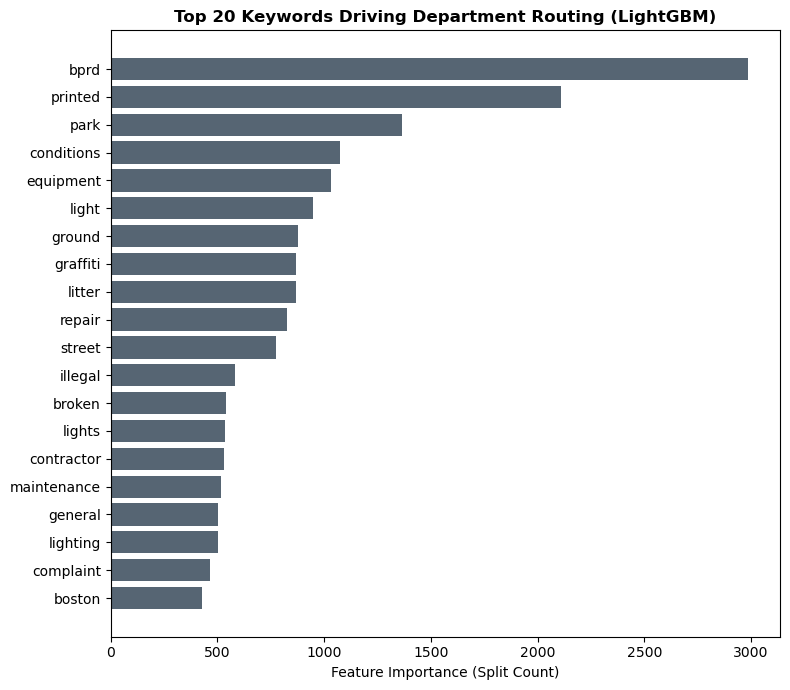

Top 20 routing keywords:
  bprd                           importance=2986
  printed                        importance=2110
  park                           importance=1366
  conditions                     importance=1076
  equipment                      importance=1031
  light                          importance=948
  ground                         importance=878
  graffiti                       importance=870
  litter                         importance=866
  repair                         importance=824
  street                         importance=776
  illegal                        importance=581
  broken                         importance=538
  lights                         importance=534
  contractor                     importance=530
  maintenance                    importance=515
  general                        importance=502
  lighting                       importance=501
  complaint                      importance=465
  boston                         importance=428


In [7]:
# Global feature importance from LightGBM (split-based, more robust than SHAP for this case)
feature_names = tfidf_router.get_feature_names_out()
importances = lgbm.feature_importances_
top_idx = np.argsort(importances)[-20:]

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(range(20), importances[top_idx], color="#2c3e50", alpha=0.8)
ax.set_yticks(range(20))
ax.set_yticklabels([feature_names[i] for i in top_idx])
ax.set_xlabel("Feature Importance (Split Count)")
ax.set_title("Top 20 Keywords Driving Department Routing (LightGBM)", fontweight="bold")
fig.tight_layout()
plt.savefig("/Users/rayxu/CS506_Final_Project/problemstic/feature_importance_routing.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 20 routing keywords:")
for i in reversed(top_idx):
    print(f"  {feature_names[i]:30s} importance={importances[i]}")

# Also prepare SHAP explainer for single-ticket demo (next cell)
import shap
explainer = shap.TreeExplainer(lgbm)

## Demo: Single Ticket Routing with Explanation

In [8]:
def route_ticket(text, tfidf, model, label_encoder, feature_names):
    """Route a single ticket and show key TF-IDF features."""
    X = tfidf.transform([text])
    pred_idx = model.predict(X)[0]
    proba = model.predict_proba(X)[0]
    dept = label_encoder.inverse_transform([pred_idx])[0]
    confidence = proba[pred_idx]
    
    # Show top TF-IDF features present in this text
    nonzero = X.nonzero()[1]
    tfidf_scores = [(feature_names[j], X[0, j]) for j in nonzero]
    tfidf_scores.sort(key=lambda x: x[1], reverse=True)
    
    # Top 3 department predictions
    top3 = np.argsort(proba)[-3:][::-1]
    
    print(f"Input: \"{text}\"")
    print(f"Predicted: {dept} ({confidence:.1%})")
    print(f"Top 3 departments: ", end="")
    print(" | ".join([f"{label_encoder.inverse_transform([i])[0]} ({proba[i]:.1%})" for i in top3]))
    print(f"Key text features: {', '.join([f'{w} ({s:.2f})' for w, s in tfidf_scores[:5]])}")
    print()

demo_tickets = [
    "Large pothole on Washington Street causing traffic issues",
    "Street light out on Boylston for 3 weeks",
    "Rats in the alley behind my building need exterminator",
    "Abandoned car blocking my driveway for a month",
    "Tree fell on power line after storm last night",
]

fn = tfidf_router.get_feature_names_out()
for ticket in demo_tickets:
    route_ticket(ticket, tfidf_router, lgbm, le, fn)
    print("-" * 60)

Input: "Large pothole on Washington Street causing traffic issues"
Predicted: PWDx (100.0%)
Top 3 departments: PWDx (100.0%) | PROP (0.0%) | PARK (0.0%)
Key text features: washington (0.77), issues (0.46), traffic (0.30), pothole (0.25), street (0.20)

------------------------------------------------------------
Input: "Street light out on Boylston for 3 weeks"
Predicted: PWDx (100.0%)
Top 3 departments: PWDx (100.0%) | PROP (0.0%) | PARK (0.0%)
Key text features: weeks (0.85), street light (0.34), light (0.33), street (0.22)

------------------------------------------------------------
Input: "Rats in the alley behind my building need exterminator"
Predicted: PWDx (100.0%)
Top 3 departments: PWDx (100.0%) | PROP (0.0%) | PARK (0.0%)
Key text features: alley (0.68), need (0.62), building (0.38)

------------------------------------------------------------
Input: "Abandoned car blocking my driveway for a month"
Predicted: PWDx (100.0%)
Top 3 departments: PWDx (100.0%) | PROP (0.0%) | PA

## Save Artifacts for Streamlit Dashboard

In [9]:
import joblib
import os

model_dir = "/Users/rayxu/CS506_Final_Project/problemstic/models"
os.makedirs(model_dir, exist_ok=True)

# Save routing model artifacts
joblib.dump(lgbm, f"{model_dir}/lgbm_router.pkl")
joblib.dump(tfidf_router, f"{model_dir}/tfidf_router.pkl")
joblib.dump(le, f"{model_dir}/label_encoder.pkl")

print(f"Saved model artifacts to {model_dir}/")
print(f"  lgbm_router.pkl: LightGBM department classifier")
print(f"  tfidf_router.pkl: TF-IDF vectorizer")
print(f"  label_encoder.pkl: Department label encoder")

Saved model artifacts to /Users/rayxu/CS506_Final_Project/problemstic/models/
  lgbm_router.pkl: LightGBM department classifier
  tfidf_router.pkl: TF-IDF vectorizer
  label_encoder.pkl: Department label encoder
